[*********************100%***********************]  1 of 1 completed


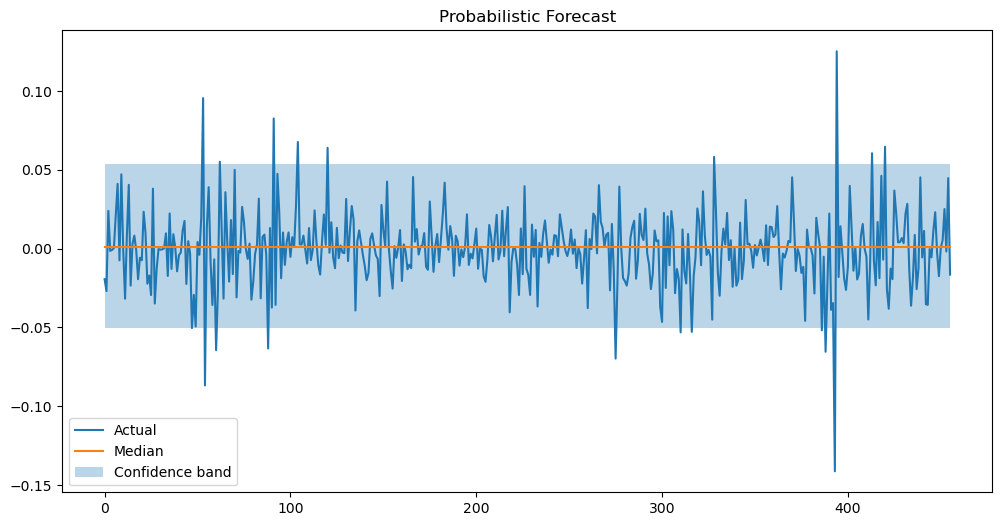

In [11]:
# ================= LAB 1 =================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import QuantileRegressor

df = yf.download("BTC-USD", start="2020-01-01")
df['ret'] = df['Close'].pct_change()

df['lag1'] = df['ret'].shift(1)
df['lag2'] = df['ret'].shift(2)
df['vol'] = df['ret'].rolling(10).std()
df.dropna(inplace=True)

X = df[['lag1','lag2','vol']]
y = df['ret']

split = int(len(df)*0.8)
X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]

q05 = QuantileRegressor(quantile=0.05, solver='highs').fit(X_train,y_train)
q50 = QuantileRegressor(quantile=0.5, solver='highs').fit(X_train,y_train)
q95 = QuantileRegressor(quantile=0.95, solver='highs').fit(X_train,y_train)

p05 = q05.predict(X_test)
p50 = q50.predict(X_test)
p95 = q95.predict(X_test)

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(p50, label="Median")
plt.fill_between(range(len(p05)), p05, p95, alpha=0.3, label="Confidence band")
plt.legend()
plt.title("Probabilistic Forecast")
plt.show()

[*********************100%***********************]  1 of 1 completed


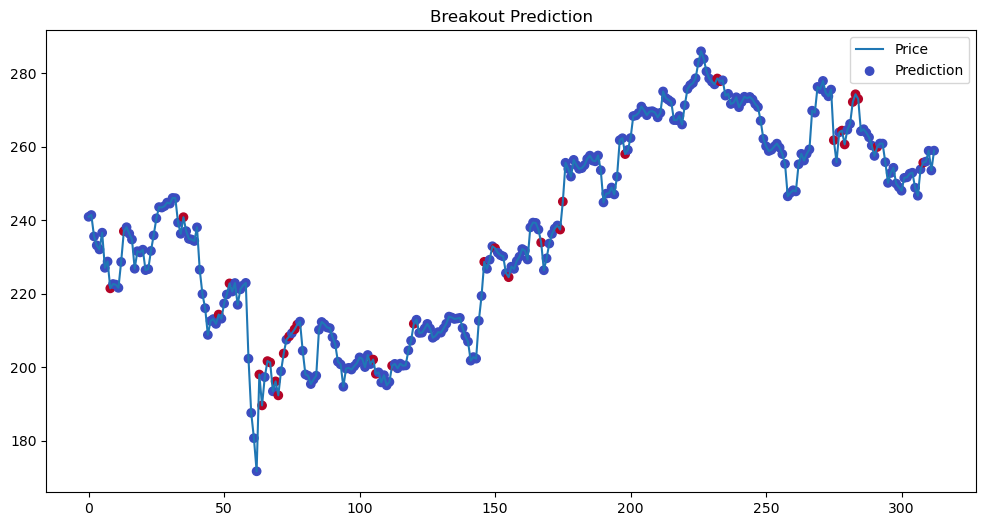

In [12]:
# ================= LAB 2 =================
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

df = yf.download("AAPL", start="2020-01-01")
df['ret'] = df['Close'].pct_change()
df['vol'] = df['ret'].rolling(10).std()

future = df['Close'].shift(-5)
df['label'] = ((future - df['Close'])/df['Close'] > 0.03).astype(int)
df.dropna(inplace=True)

X = df[['ret','vol']]
y = df['label']

split = int(len(df)*0.8)
model = XGBClassifier().fit(X[:split],y[:split])
pred = model.predict(X[split:])

plt.figure(figsize=(12,6))
plt.plot(df['Close'][split:].values, label="Price")
plt.scatter(range(len(pred)), df['Close'][split:].values, 
            c=pred, cmap='coolwarm', label="Prediction")
plt.legend()
plt.title("Breakout Prediction")
plt.show()

[*********************100%***********************]  1 of 1 completed


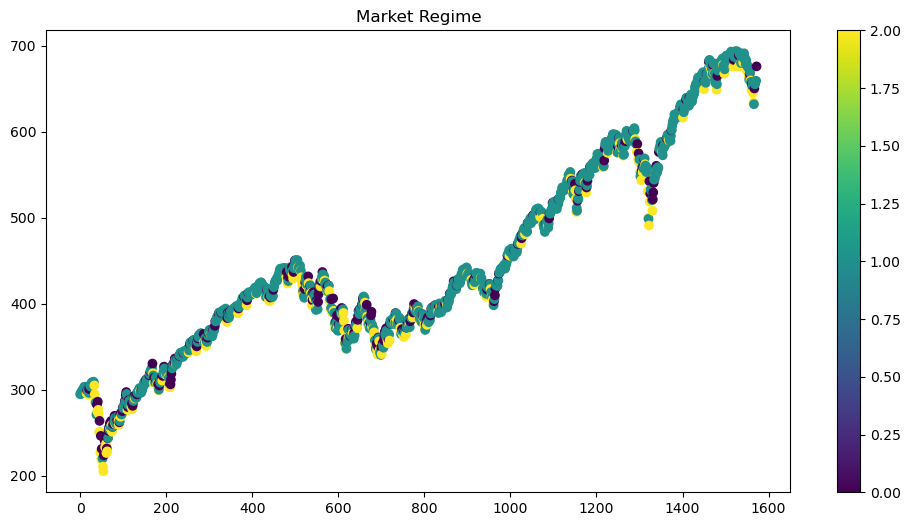

In [13]:
# ================= LAB 3 =================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = yf.download("SPY", start="2020-01-01")
df['ret'] = df['Close'].pct_change()

df['regime'] = np.select(
    [df['ret']>0.01, df['ret']<-0.01],
    [0,2], default=1
)

df.dropna(inplace=True)

plt.figure(figsize=(12,6))
plt.scatter(range(len(df)), df['Close'], c=df['regime'], cmap='viridis')
plt.title("Market Regime")
plt.colorbar()
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


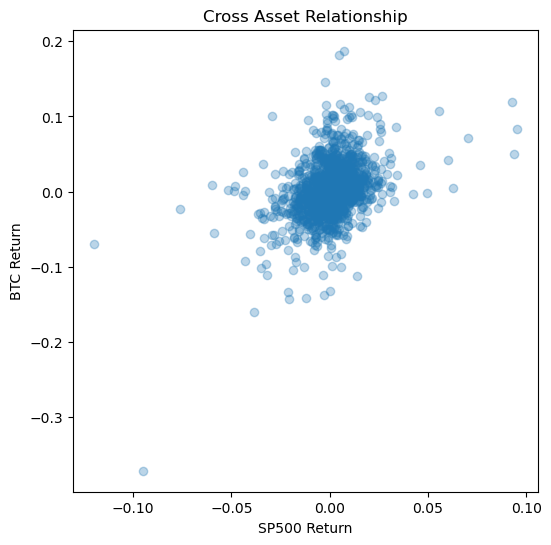

In [14]:
# ================= LAB 4 =================
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

btc = yf.download("BTC-USD", start="2020-01-01")
sp = yf.download("^GSPC", start="2020-01-01")

df = pd.DataFrame()
df['btc_ret'] = btc['Close'].pct_change()
df['sp_ret'] = sp['Close'].pct_change()
df.dropna(inplace=True)

plt.figure(figsize=(6,6))
plt.scatter(df['sp_ret'], df['btc_ret'], alpha=0.3)
plt.xlabel("SP500 Return")
plt.ylabel("BTC Return")
plt.title("Cross Asset Relationship")
plt.show()

[*********************100%***********************]  1 of 1 completed


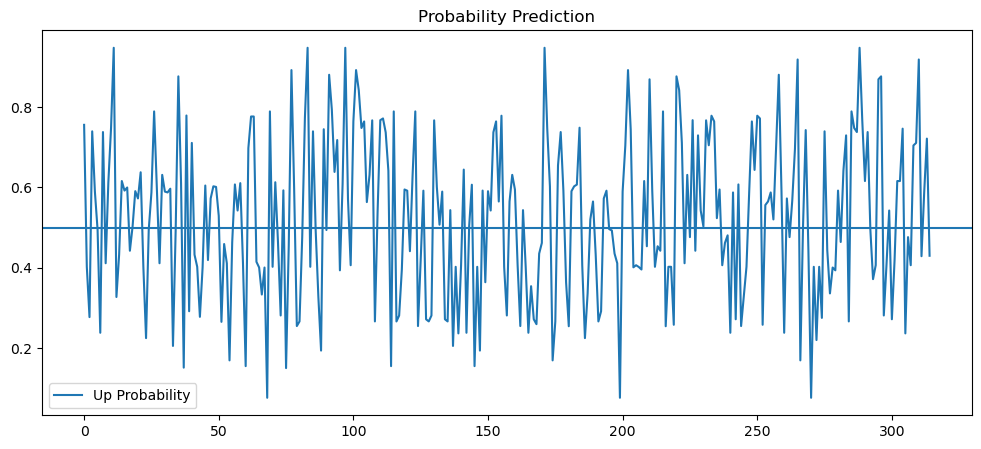

In [15]:
# ================= LAB 5 =================
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

df = yf.download("AAPL", start="2020-01-01")
df['ret'] = df['Close'].pct_change()
df['label'] = (df['ret']>0).astype(int)
df['lag1'] = df['ret'].shift(1)
df.dropna(inplace=True)

X = df[['lag1']]
y = df['label']

split = int(len(df)*0.8)
model = XGBClassifier().fit(X[:split],y[:split])
proba = model.predict_proba(X[split:])[:,1]

plt.figure(figsize=(12,5))
plt.plot(proba, label="Up Probability")
plt.axhline(0.5)
plt.legend()
plt.title("Probability Prediction")
plt.show()

[*********************100%***********************]  1 of 1 completed


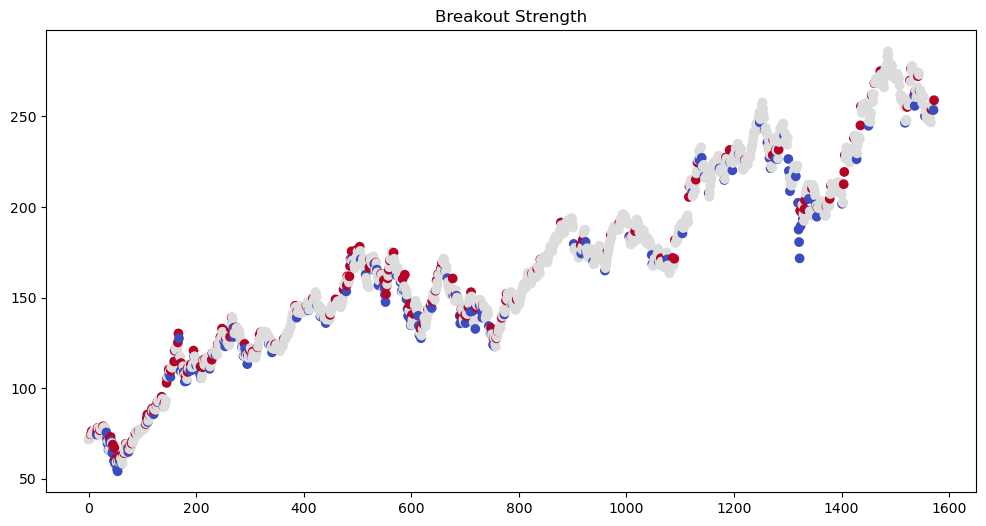

In [16]:
# ================= LAB 6 =================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = yf.download("AAPL", start="2020-01-01")
df['ret'] = df['Close'].pct_change()

df['label'] = np.select(
    [df['ret']>0.02, df['ret']<-0.02],
    [2,0], default=1
)

df.dropna(inplace=True)

plt.figure(figsize=(12,6))
plt.scatter(range(len(df)), df['Close'], c=df['label'], cmap='coolwarm')
plt.title("Breakout Strength")
plt.show()

[*********************100%***********************]  1 of 1 completed


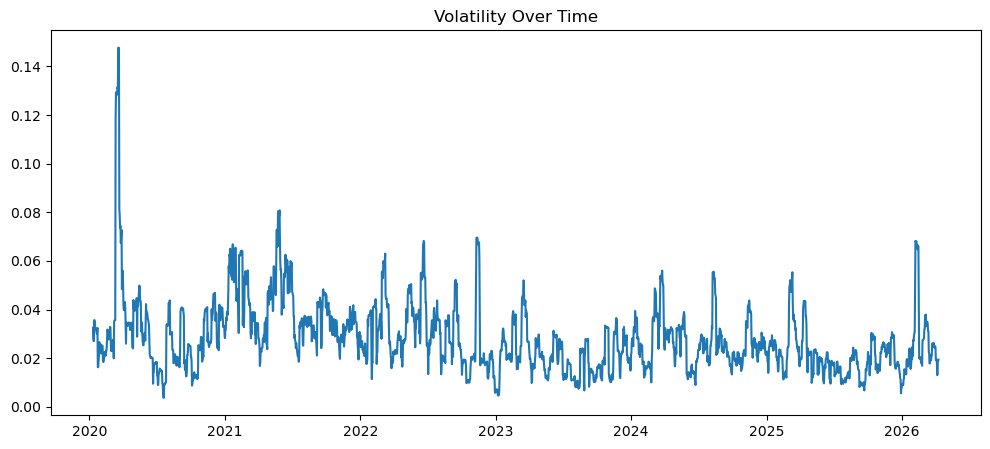

In [17]:
# ================= LAB 7 =================
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

df = yf.download("BTC-USD", start="2020-01-01")
df['ret'] = df['Close'].pct_change()
df['vol'] = df['ret'].rolling(10).std()

plt.figure(figsize=(12,5))
plt.plot(df['vol'])
plt.title("Volatility Over Time")
plt.show()

[*********************100%***********************]  1 of 1 completed


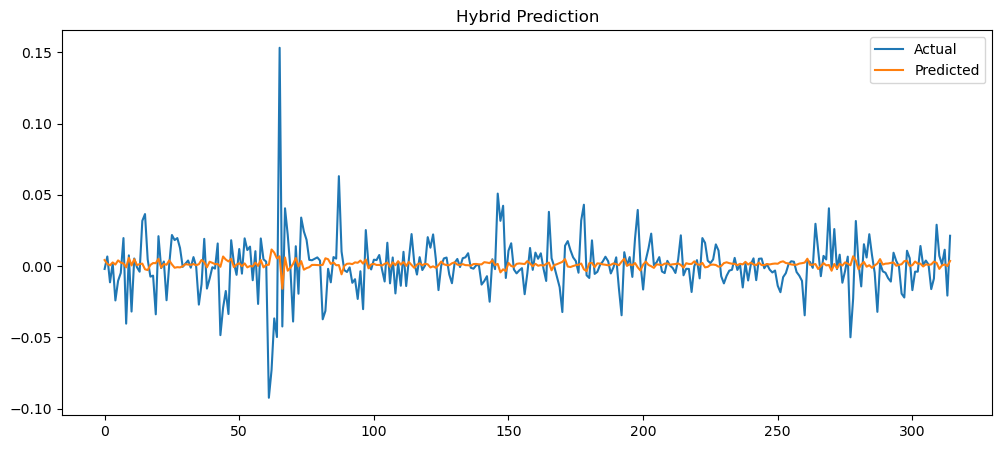

In [18]:
# ================= LAB 8 =================
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = yf.download("AAPL", start="2020-01-01")
df['ret'] = df['Close'].pct_change()
df['lag1'] = df['ret'].shift(1)
df.dropna(inplace=True)

X = df[['lag1']]
y = df['ret']

split = int(len(df)*0.8)
model = LinearRegression().fit(X[:split],y[:split])
pred = model.predict(X[split:])

plt.figure(figsize=(12,5))
plt.plot(y[split:].values, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Hybrid Prediction")
plt.show()

[*********************100%***********************]  1 of 1 completed


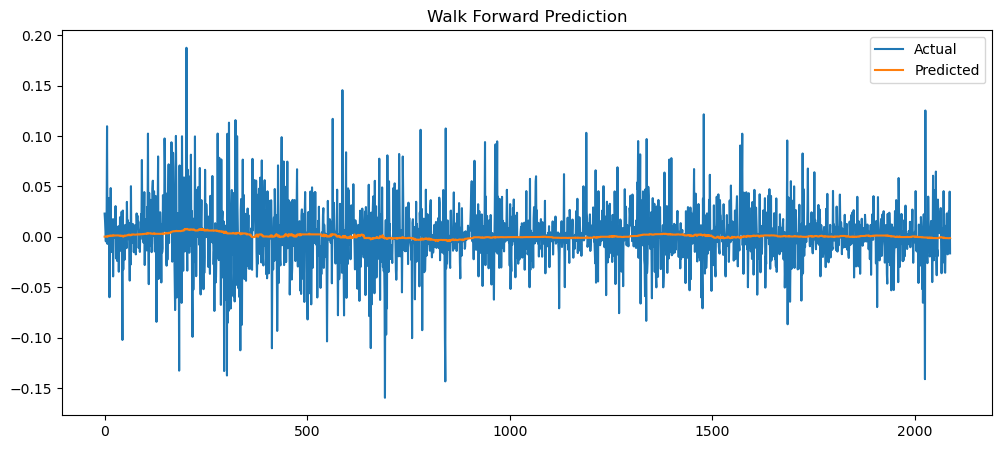

In [20]:
# ================= LAB 9 =================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import QuantileRegressor

df = yf.download("BTC-USD", start="2020-01-01")
df['ret'] = df['Close'].pct_change()
df['lag1'] = df['ret'].shift(1)
df.dropna(inplace=True)

window = 200
preds = []
actual = []

for i in range(window, len(df)):
    train = df.iloc[i-window:i]
    test = df.iloc[i:i+1]

    model = QuantileRegressor(quantile=0.5, solver='highs').fit(train[['lag1']], train['ret'])
    preds.append(model.predict(test[['lag1']])[0])
    actual.append(test['ret'].values[0])

plt.figure(figsize=(12,5))
plt.plot(actual, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("Walk Forward Prediction")
plt.show()